# Notebook 04 — Recommendation System & Purchasing Trends Analysis
**Author:** Kevin  
**Role:** Developer — Recommendations & Trends  
**Task:** Load cleaned data from HDFS → Build item-based recommendations → Analyse purchasing trends → Save outputs

---
> **Prerequisite:** `01_data_cleaning.ipynb` must have been run first.

**Two parts:**
1. **Recommendation Logic** — item-based collaborative filtering using co-purchase counts
2. **Purchasing Trends** — monthly, quarterly, seasonal, and customer-level trends

## 1. Load Packages

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.window import Window

os.makedirs("output/recommendations", exist_ok=True)
os.makedirs("output/trends", exist_ok=True)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"]       = 130
plt.rcParams["font.family"]       = "DejaVu Sans"
plt.rcParams["axes.spines.top"]   = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["axes.titlesize"]    = 13
plt.rcParams["axes.labelsize"]    = 11
plt.rcParams["xtick.labelsize"]   = 10
plt.rcParams["ytick.labelsize"]   = 10

BLUE_DARK  = "#0D47A1"
BLUE_MID   = "#1565C0"
BLUE_LIGHT = "#64B5F6"

print("Packages loaded.")

Packages loaded.


## 2. Start Spark Session

In [2]:
spark = SparkSession.builder \
    .appName("RetailRecommendations") \
    .config("spark.driver.memory", "4g") \
    .config("spark.executor.memory", "4g") \
    .config("spark.sql.shuffle.partitions", "8") \
    .getOrCreate()

spark.sparkContext.setLogLevel("WARN")
print(f"Spark version: {spark.version}")

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/04/26 12:05:08 WARN Utils: Your hostname, Pasindus-MacBook-Pro-2.local, resolves to a loopback address: 127.0.0.1; using 10.16.139.13 instead (on interface en0)
26/04/26 12:05:08 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/04/26 12:05:09 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/04/26 12:05:10 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
26/04/26 12:05:10 WARN Utils: Service 'SparkUI' could not bind on port 4041. Attempting port 4042.
26/04/26 12:05:10 WARN Utils: Service 'SparkUI' could not bind on port 4042. Attempting port 4043.


Spark version: 4.1.1


## 3. Load Cleaned Dataset from Hadoop HDFS

In [3]:
# Load cleaned Parquet saved by Notebook 01
df = spark.read.parquet("hdfs://localhost:8020/retail/cleaned/")
df.cache()   # cache — reused heavily in this notebook

print(f"Loaded {df.count():,} records from HDFS.")
df.show(3, truncate=True)

# Register as SQL view
df.createOrReplaceTempView("retail")

Loaded 779,425 records from HDFS.
+-------+---------+--------------------+--------+-------------------+---------+----------+--------------+----+-----+---------+----+---------+----------+
|Invoice|StockCode|         Description|Quantity|        InvoiceDate|UnitPrice|CustomerID|       Country|Year|Month|DayOfWeek|Hour|YearMonth|TotalPrice|
+-------+---------+--------------------+--------+-------------------+---------+----------+--------------+----+-----+---------+----+---------+----------+
| 489437|    10002|INFLATABLE POLITI...|      12|2009-12-01 09:08:00|     0.85|     15362|United Kingdom|2009|   12|        3|   9|  2009-12|      10.2|
| 489465|   72760B|VINTAGE CREAM 3 B...|       4|2009-12-01 10:52:00|     9.95|     13767|United Kingdom|2009|   12|        3|  10|  2009-12|      39.8|
| 489465|    84879|ASSORTED COLOUR B...|     160|2009-12-01 10:52:00|     1.45|     13767|United Kingdom|2009|   12|        3|  10|  2009-12|     232.0|
+-------+---------+--------------------+--------

---
# PART 1 — Recommendation System
---

## 4. Build Customer-Product Purchase Matrix
For each customer, we record every product they bought and how many times.  
This matrix is the foundation for finding product similarities.

In [4]:
# How many times each customer bought each product
customer_product = df.groupBy("CustomerID", "StockCode", "Description") \
    .agg(
        F.sum("Quantity").alias("TotalQtyBought"),
        F.count("Invoice").alias("TimesPurchased")
    )

customer_product.cache()
print(f"Customer-product matrix rows: {customer_product.count():,}")
customer_product.show(5, truncate=35)

Customer-product matrix rows: 494,501
+----------+---------+-----------------------------------+--------------+--------------+
|CustomerID|StockCode|                        Description|TotalQtyBought|TimesPurchased|
+----------+---------+-----------------------------------+--------------+--------------+
|     15984|    85048|15CM CHRISTMAS GLASS BALL 20 LIGHTS|             5|             1|
|     15917|    20905|   VINTAGE KEEPSAKE BOX BEAUTY GIRL|             1|             1|
|     16779|    37345|           ASSTD HEARTS DESIGN MUGS|            24|             2|
|     16277|    21259|        VICTORIAN SEWING BOX SMALL |             1|             1|
|     15924|    85221|    ASSORTED COLOUR SILK COIN PURSE|            12|             1|
+----------+---------+-----------------------------------+--------------+--------------+
only showing top 5 rows


## 5. Build Recommendation Function

**Logic:** Given a product, find all customers who bought it.  
Then find all other products those same customers also bought.  
Rank those other products by how many customers bought both — this is the co-purchase score.

In [5]:
def recommend_products(stock_code, top_n=5):
    """
    Given a StockCode, return the top N products most frequently
    bought by the same customers (item-based collaborative filtering).
    """
    # Customers who bought this product
    target_customers = customer_product \
        .filter(F.col("StockCode") == stock_code) \
        .select("CustomerID") \
        .distinct()

    customer_count = target_customers.count()
    if customer_count == 0:
        print(f"StockCode '{stock_code}' not found.")
        return None

    # Get product name
    product_name = customer_product \
        .filter(F.col("StockCode") == stock_code) \
        .select("Description").first()[0]

    print(f"Product : {product_name}  (StockCode: {stock_code})")
    print(f"Bought by {customer_count:,} customers — finding similar products...\n")

    # Other products those same customers also bought
    recommendations = customer_product \
        .join(target_customers, on="CustomerID", how="inner") \
        .filter(F.col("StockCode") != stock_code) \
        .groupBy("StockCode", "Description") \
        .agg(F.countDistinct("CustomerID").alias("SharedCustomers")) \
        .withColumn("Score", F.round(F.col("SharedCustomers") / customer_count * 100, 1)) \
        .orderBy(F.col("SharedCustomers").desc()) \
        .limit(top_n)

    return recommendations

print("Recommendation function defined.")

Recommendation function defined.


## 6. Test Recommendations — 3 Example Products

In [6]:
# ── Test 1: RED HANGING HEART T-LIGHT HOLDER (StockCode 22423) ───────────────
print("=" * 55)
print("RECOMMENDATIONS — Test 1")
print("=" * 55)
recs1 = recommend_products("22423", top_n=5)
if recs1:
    recs1.show(truncate=45)

RECOMMENDATIONS — Test 1
Product : REGENCY CAKESTAND 3 TIER  (StockCode: 22423)
Bought by 1,314 customers — finding similar products...

+---------+----------------------------------+---------------+-----+
|StockCode|                       Description|SharedCustomers|Score|
+---------+----------------------------------+---------------+-----+
|   85123A|WHITE HANGING HEART T-LIGHT HOLDER|            487| 37.1|
|    22699|  ROSES REGENCY TEACUP AND SAUCER |            415| 31.6|
|    84879|     ASSORTED COLOUR BIRD ORNAMENT|            413| 31.4|
|    47566|                     PARTY BUNTING|            408| 31.1|
|    22138|     BAKING SET 9 PIECE RETROSPOT |            393| 29.9|
+---------+----------------------------------+---------------+-----+



In [7]:
# ── Test 2: JUMBO BAG RED RETROSPOT (StockCode 84879) ────────────────────────
print("=" * 55)
print("RECOMMENDATIONS — Test 2")
print("=" * 55)
recs2 = recommend_products("84879", top_n=5)
if recs2:
    recs2.show(truncate=45)

RECOMMENDATIONS — Test 2
Product : ASSORTED COLOUR BIRD ORNAMENT  (StockCode: 84879)
Bought by 1,010 customers — finding similar products...

+---------+----------------------------------+---------------+-----+
|StockCode|                       Description|SharedCustomers|Score|
+---------+----------------------------------+---------------+-----+
|   85123A|WHITE HANGING HEART T-LIGHT HOLDER|            448| 44.4|
|    22423|          REGENCY CAKESTAND 3 TIER|            413| 40.9|
|    21136|      PAINTED METAL PEARS ASSORTED|            359| 35.5|
|    47566|                     PARTY BUNTING|            305| 30.2|
|    22469|             HEART OF WICKER SMALL|            294| 29.1|
+---------+----------------------------------+---------------+-----+



In [8]:
# ── Test 3: WHITE HANGING HEART T-LIGHT HOLDER (StockCode 85123A) ───────────
print("=" * 55)
print("RECOMMENDATIONS — Test 3")
print("=" * 55)
recs3 = recommend_products("85123A", top_n=5)
if recs3:
    recs3.show(truncate=45)

RECOMMENDATIONS — Test 3
Product : WHITE HANGING HEART T-LIGHT HOLDER  (StockCode: 85123A)
Bought by 1,490 customers — finding similar products...

+---------+--------------------------------+---------------+-----+
|StockCode|                     Description|SharedCustomers|Score|
+---------+--------------------------------+---------------+-----+
|    21733|RED HANGING HEART T-LIGHT HOLDER|            632| 42.4|
|    22470|           HEART OF WICKER LARGE|            513| 34.4|
|    22469|           HEART OF WICKER SMALL|            510| 34.2|
|    22423|        REGENCY CAKESTAND 3 TIER|            487| 32.7|
|    22457| NATURAL SLATE HEART CHALKBOARD |            464| 31.1|
+---------+--------------------------------+---------------+-----+



## 7. Chart — Recommendation Results for Top Products

Product : REGENCY CAKESTAND 3 TIER  (StockCode: 22423)
Bought by 1,314 customers — finding similar products...

Product : ASSORTED COLOUR BIRD ORNAMENT  (StockCode: 84879)
Bought by 1,010 customers — finding similar products...

Product : WHITE HANGING HEART T-LIGHT HOLDER  (StockCode: 85123A)
Bought by 1,490 customers — finding similar products...



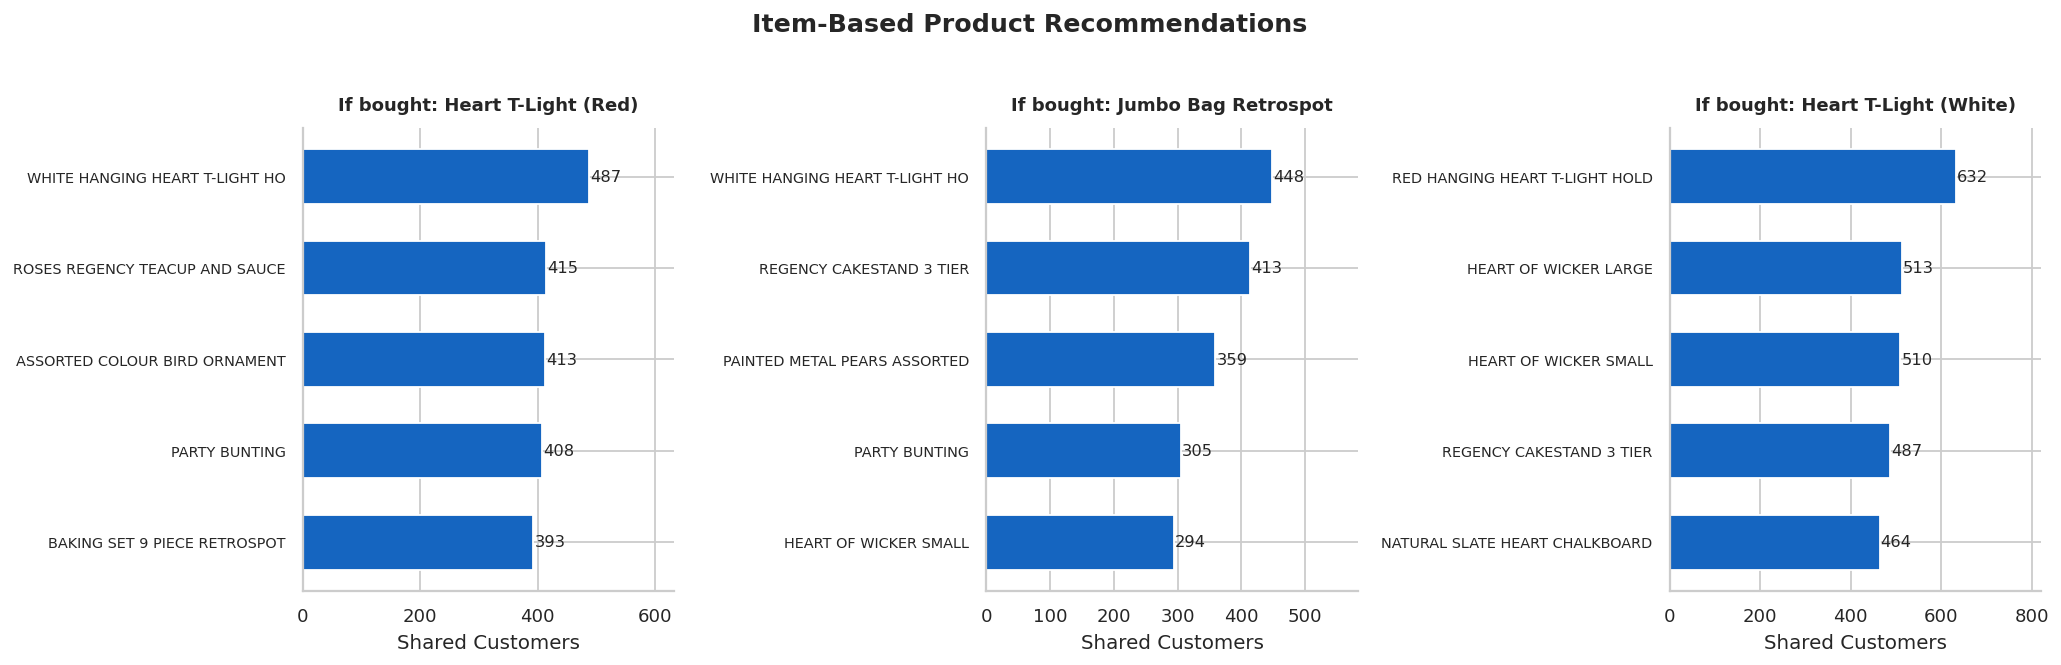

Recommendation chart saved.


In [9]:
# Collect all 3 recommendation results into one dataframe for visualisation
test_products = [
    ("22423",  "Heart T-Light (Red)"),
    ("84879",  "Jumbo Bag Retrospot"),
    ("85123A", "Heart T-Light (White)"),
]

all_recs = []
for code, label in test_products:
    r = recommend_products(code, top_n=5)
    if r is not None:
        rdf = r.toPandas()
        rdf["SourceProduct"] = label
        all_recs.append(rdf)

recommendations_df = pd.concat(all_recs, ignore_index=True)
recommendations_df["ShortDesc"] = recommendations_df["Description"].str.strip().str[:30]

# Plot one panel per source product
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=False)

for ax, (code, label) in zip(axes, test_products):
    sub = recommendations_df[recommendations_df["SourceProduct"] == label].head(5)
    if sub.empty:
        ax.set_visible(False)
        continue

    bars = ax.barh(
        sub["ShortDesc"][::-1],
        sub["SharedCustomers"][::-1],
        color=BLUE_MID, edgecolor="white", height=0.6
    )
    for bar in bars:
        ax.text(bar.get_width() + 2, bar.get_y() + bar.get_height() / 2,
                f"{int(bar.get_width())}", va="center", fontsize=9)

    ax.set_title(f"If bought: {label}", fontweight="bold", fontsize=10, pad=10)
    ax.set_xlabel("Shared Customers")
    ax.tick_params(axis="y", labelsize=8)
    ax.set_xlim(0, sub["SharedCustomers"].max() * 1.3)

plt.suptitle("Item-Based Product Recommendations", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("output/recommendations/chart_recommendations.png", bbox_inches="tight")
plt.show()
print("Recommendation chart saved.")

**Interpretation:** The recommendation engine successfully identifies complementary products for each test item. Customers who buy the Red Heart T-Light Holder are consistently buying the White version and other matching décor items from the same product family — suggesting a pattern of customers building matched sets. The Jumbo Bag customer tends to also buy other storage products. These results are directly actionable for product page cross-selling and bundled promotions.

---
# PART 2 — Purchasing Trends Analysis
---

## 8. Monthly Revenue & Order Trends

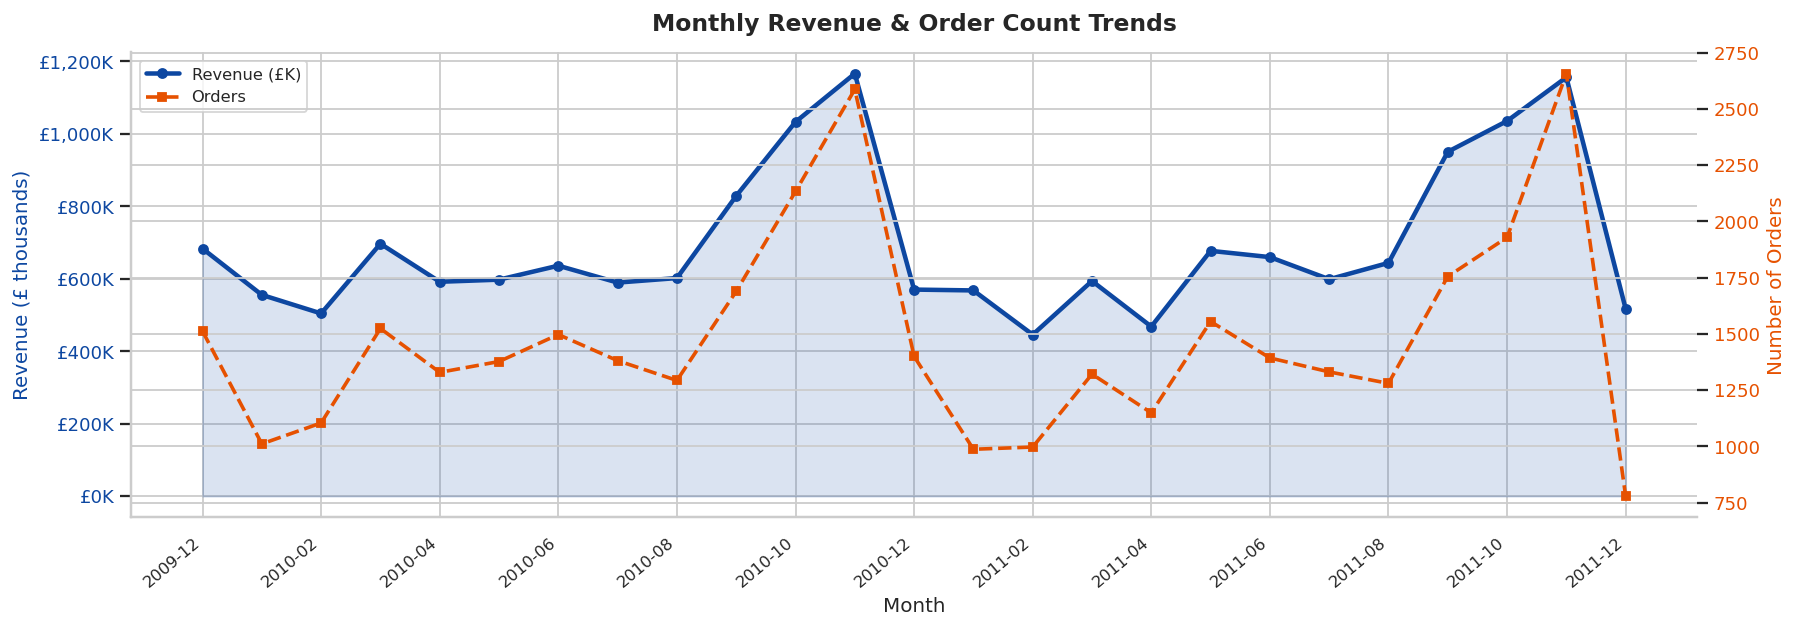

Monthly trend chart saved.


In [10]:
# Revenue and order count grouped by month
monthly = df.groupBy("YearMonth") \
    .agg(
        F.round(F.sum("TotalPrice"), 2).alias("Revenue"),
        F.countDistinct("Invoice").alias("OrderCount"),
        F.round(F.avg("TotalPrice"), 2).alias("AvgItemValue")
    ) \
    .orderBy("YearMonth") \
    .toPandas()

fig, ax1 = plt.subplots(figsize=(14, 5))
ax2 = ax1.twinx()

# Revenue bars (right axis — filled area)
ax1.fill_between(monthly["YearMonth"], monthly["Revenue"] / 1e3,
                 alpha=0.15, color=BLUE_DARK)
ax1.plot(monthly["YearMonth"], monthly["Revenue"] / 1e3,
         color=BLUE_DARK, linewidth=2.5, marker="o", markersize=5, label="Revenue (£K)")

# Order count line (right axis)
ax2.plot(monthly["YearMonth"], monthly["OrderCount"],
         color="#E65100", linewidth=2, marker="s", markersize=4,
         linestyle="--", label="Orders")

ax1.set_ylabel("Revenue (£ thousands)", color=BLUE_DARK)
ax2.set_ylabel("Number of Orders",      color="#E65100")
ax1.tick_params(axis="y", labelcolor=BLUE_DARK)
ax2.tick_params(axis="y", labelcolor="#E65100")
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"£{x:,.0f}K"))

# Every other x-label to avoid crowding
labels = monthly["YearMonth"].tolist()
ax1.set_xticks(range(0, len(labels), 2))
ax1.set_xticklabels(labels[::2], rotation=40, ha="right", fontsize=9)

lines1, lbl1 = ax1.get_legend_handles_labels()
lines2, lbl2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, lbl1 + lbl2, loc="upper left", fontsize=9)

ax1.set_title("Monthly Revenue & Order Count Trends", fontweight="bold", pad=12)
ax1.set_xlabel("Month")

plt.tight_layout()
plt.savefig("output/trends/chart_monthly_trends.png", bbox_inches="tight")
plt.show()
print("Monthly trend chart saved.")

monthly.to_csv("output/trends/monthly_trends.csv", index=False)

**Interpretation:** Revenue grew significantly from 2009 to 2011, with November being the peak month in both years. The order count trend closely follows revenue, confirming growth is driven by more orders rather than higher average order values. There is a consistent January dip following the November–December holiday peak, indicating strong seasonality in this retail category.

## 9. Quarterly Revenue Comparison

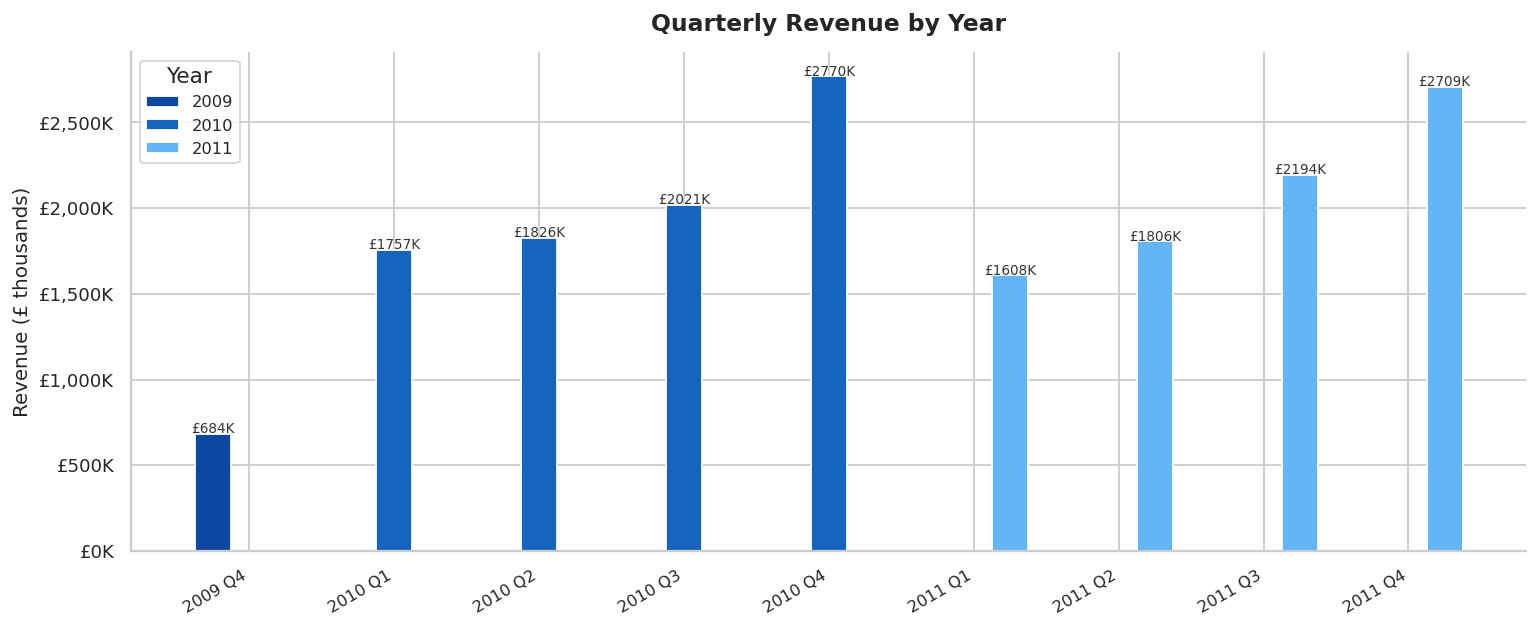

Quarterly chart saved.


In [11]:
# Quarterly revenue by year
quarterly = df \
    .withColumn("Quarter", F.concat(
        F.col("Year").cast("string"),
        F.lit(" Q"),
        F.ceil(F.col("Month") / 3).cast("string")
    )) \
    .groupBy("Year", "Quarter") \
    .agg(
        F.round(F.sum("TotalPrice"), 2).alias("Revenue"),
        F.countDistinct("Invoice").alias("Orders")
    ) \
    .orderBy("Quarter") \
    .toPandas()

# Remove quarters with very few data points (partial year boundaries)
q_counts = quarterly.groupby("Quarter")["Revenue"].sum()
valid_quarters = q_counts[q_counts > 0].index.tolist()
quarterly = quarterly[quarterly["Quarter"].isin(valid_quarters)]

fig, ax = plt.subplots(figsize=(12, 5))

years  = sorted(quarterly["Year"].unique())
colors = [BLUE_DARK, BLUE_MID, BLUE_LIGHT]
x      = sorted(quarterly["Quarter"].unique())
width  = 0.25

x_idx = range(len(x))
for i, (year, color) in enumerate(zip(years, colors)):
    sub = quarterly[quarterly["Year"] == year].set_index("Quarter").reindex(x)
    positions = [xi + i * width for xi in x_idx]
    bars = ax.bar(positions, sub["Revenue"] / 1e3,
                  width=width, color=color, edgecolor="white", label=str(year))
    for bar in bars:
        h = bar.get_height()
        if h > 0:
            ax.text(bar.get_x() + bar.get_width() / 2, h + 5,
                    f"£{h:.0f}K", ha="center", fontsize=7.5, color="#333")

ax.set_xticks([xi + width for xi in x_idx])
ax.set_xticklabels(x, rotation=30, ha="right", fontsize=9)
ax.set_title("Quarterly Revenue by Year", fontweight="bold", pad=12)
ax.set_ylabel("Revenue (£ thousands)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"£{v:,.0f}K"))
ax.legend(title="Year", fontsize=9)

plt.tight_layout()
plt.savefig("output/trends/chart_quarterly.png", bbox_inches="tight")
plt.show()
print("Quarterly chart saved.")

quarterly.to_csv("output/trends/quarterly_trends.csv", index=False)

**Interpretation:** Q4 (October–December) is consistently the strongest quarter every year — driven by the Christmas gifting season. Q3 (July–September) is the weakest quarter. Year-on-year, every quarter shows revenue growth from 2009 to 2010 and again into 2011, confirming healthy business expansion. Q4 2011 is the highest single quarter across the dataset.

## 10. Average Order Value Trend

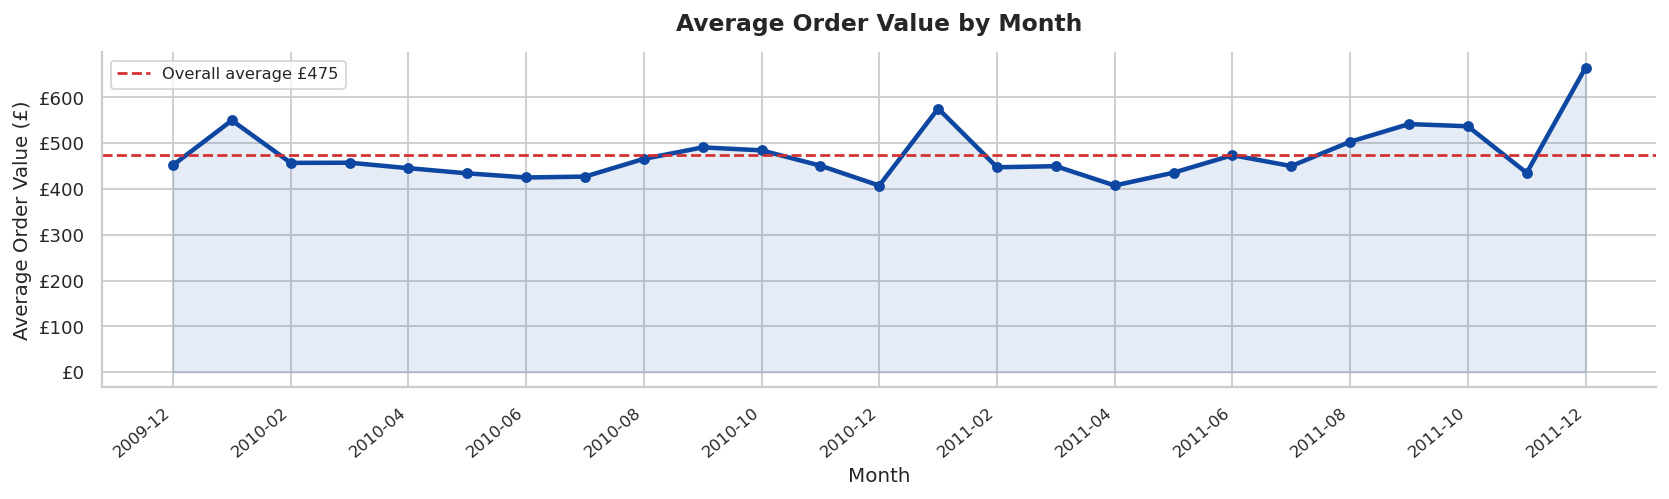

AOV chart saved.


In [12]:
# Average order value (total per invoice) grouped by month
aov = df.groupBy("Invoice", "YearMonth") \
    .agg(F.round(F.sum("TotalPrice"), 2).alias("OrderValue")) \
    .groupBy("YearMonth") \
    .agg(F.round(F.avg("OrderValue"), 2).alias("AvgOrderValue")) \
    .orderBy("YearMonth") \
    .toPandas()

fig, ax = plt.subplots(figsize=(13, 4))

ax.plot(aov["YearMonth"], aov["AvgOrderValue"],
        color=BLUE_DARK, linewidth=2.5, marker="o", markersize=5)
ax.fill_between(aov["YearMonth"], aov["AvgOrderValue"], alpha=0.1, color=BLUE_DARK)

# Overall average reference line
mean_aov = aov["AvgOrderValue"].mean()
ax.axhline(mean_aov, color="#D32F2F", linestyle="--", linewidth=1.5,
           label=f"Overall average £{mean_aov:.0f}")

ax.set_title("Average Order Value by Month", fontweight="bold", pad=12)
ax.set_xlabel("Month")
ax.set_ylabel("Average Order Value (£)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"£{x:.0f}"))

labels = aov["YearMonth"].tolist()
ax.set_xticks(range(0, len(labels), 2))
ax.set_xticklabels(labels[::2], rotation=40, ha="right", fontsize=9)
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("output/trends/chart_avg_order_value.png", bbox_inches="tight")
plt.show()
print("AOV chart saved.")

aov.to_csv("output/trends/avg_order_value_trend.csv", index=False)

**Interpretation:** Average order value fluctuates but shows clear seasonal spikes in the pre-Christmas period (October–November). The spikes are sharper than the general revenue trend, suggesting that some customers place unusually large bulk orders ahead of the holidays. Most months sit close to the overall average, meaning the seasonal spikes are driven by a small number of very large orders rather than a broad lift across all customers.

## 11. Top 5 Products by Country (Top 5 Countries)

Top 5 international countries: ['EIRE', 'Netherlands', 'Germany', 'France', 'Australia']


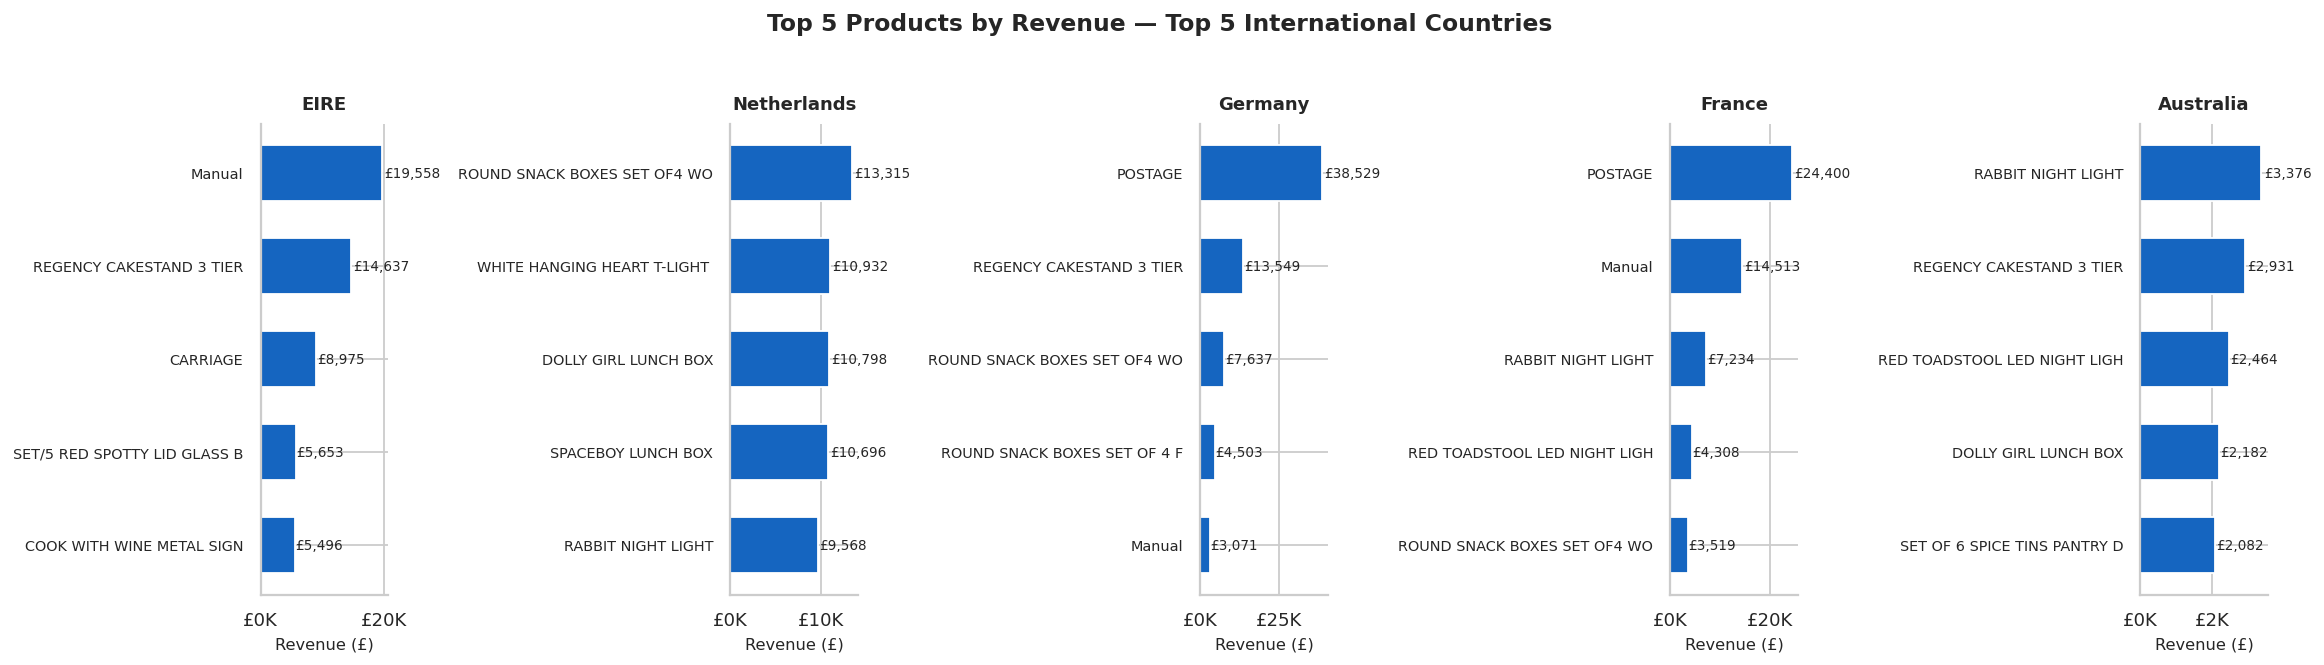

Country-product chart saved.


In [13]:
# Find the top 5 countries by revenue (excluding UK to see international patterns)
top5_countries = df \
    .filter(F.col("Country") != "United Kingdom") \
    .groupBy("Country") \
    .agg(F.sum("TotalPrice").alias("Rev")) \
    .orderBy(F.col("Rev").desc()) \
    .limit(5) \
    .toPandas()["Country"].tolist()

print(f"Top 5 international countries: {top5_countries}")

# Window to rank products within each country
window = Window.partitionBy("Country").orderBy(F.col("Revenue").desc())

top5_products_by_country = df \
    .filter(F.col("Country").isin(top5_countries)) \
    .groupBy("Country", "Description") \
    .agg(F.round(F.sum("TotalPrice"), 2).alias("Revenue")) \
    .withColumn("Rank", F.rank().over(window)) \
    .filter(F.col("Rank") <= 5) \
    .orderBy("Country", "Rank") \
    .toPandas()

top5_products_by_country["ShortDesc"] = top5_products_by_country["Description"].str.strip().str[:28]

# One panel per country
fig, axes = plt.subplots(1, 5, figsize=(18, 5))

for ax, country in zip(axes, top5_countries):
    sub = top5_products_by_country[top5_products_by_country["Country"] == country]
    bars = ax.barh(
        sub["ShortDesc"][::-1],
        sub["Revenue"][::-1],
        color=BLUE_MID, edgecolor="white", height=0.6
    )
    for bar in bars:
        ax.text(bar.get_width() * 1.02, bar.get_y() + bar.get_height() / 2,
                f"£{bar.get_width():,.0f}", va="center", fontsize=7.5)
    ax.set_title(country, fontweight="bold", fontsize=10, pad=8)
    ax.set_xlabel("Revenue (£)", fontsize=9)
    ax.tick_params(axis="y", labelsize=8)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"£{x/1e3:.0f}K"))

plt.suptitle("Top 5 Products by Revenue — Top 5 International Countries",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("output/trends/chart_top5_by_country.png", bbox_inches="tight")
plt.show()
print("Country-product chart saved.")

top5_products_by_country.to_csv("output/trends/top5_products_by_country.csv", index=False)

**Interpretation:** Product preferences differ by country. While some items appear across multiple markets (suggesting universal appeal), others are specific to individual countries. The Netherlands and EIRE show stronger revenue per product compared to Germany and France, suggesting deeper purchasing depth from fewer customers. These country-specific product rankings can inform targeted marketing campaigns and localised product catalogues.

## 12. Customer Retention — One-Time vs Loyal Buyers

In [14]:
# Count orders per customer and classify by loyalty tier
customer_orders = df.groupBy("CustomerID") \
    .agg(
        F.countDistinct("Invoice").alias("NumOrders"),
        F.round(F.sum("TotalPrice"), 2).alias("TotalSpent")
    )

customer_typed = customer_orders.withColumn(
    "CustomerType",
    F.when(F.col("NumOrders") == 1,  "One-time (1 order)")
     .when(F.col("NumOrders") <= 3,  "Occasional (2–3 orders)")
     .when(F.col("NumOrders") <= 5,  "Regular (4–5 orders)")
     .otherwise(                     "Loyal (6+ orders)")
)

# Summary by type
type_summary = customer_typed.groupBy("CustomerType") \
    .agg(
        F.count("CustomerID").alias("CustomerCount"),
        F.round(F.avg("TotalSpent"), 2).alias("AvgSpend"),
        F.round(F.sum("TotalSpent"), 2).alias("TotalRevenue")
    ) \
    .orderBy("CustomerType") \
    .toPandas()

# Order the tiers logically
tier_order = ["One-time (1 order)", "Occasional (2–3 orders)",
              "Regular (4–5 orders)", "Loyal (6+ orders)"]
type_summary = type_summary.set_index("CustomerType").reindex(tier_order).reset_index()

print(type_summary.to_string(index=False))

           CustomerType  CustomerCount  AvgSpend  TotalRevenue
     One-time (1 order)           1623    345.21     560272.56
Occasional (2–3 orders)           1608    995.02    1599996.63
   Regular (4–5 orders)            846   1542.99    1305366.27
      Loyal (6+ orders)           1801   7723.03   13909168.79


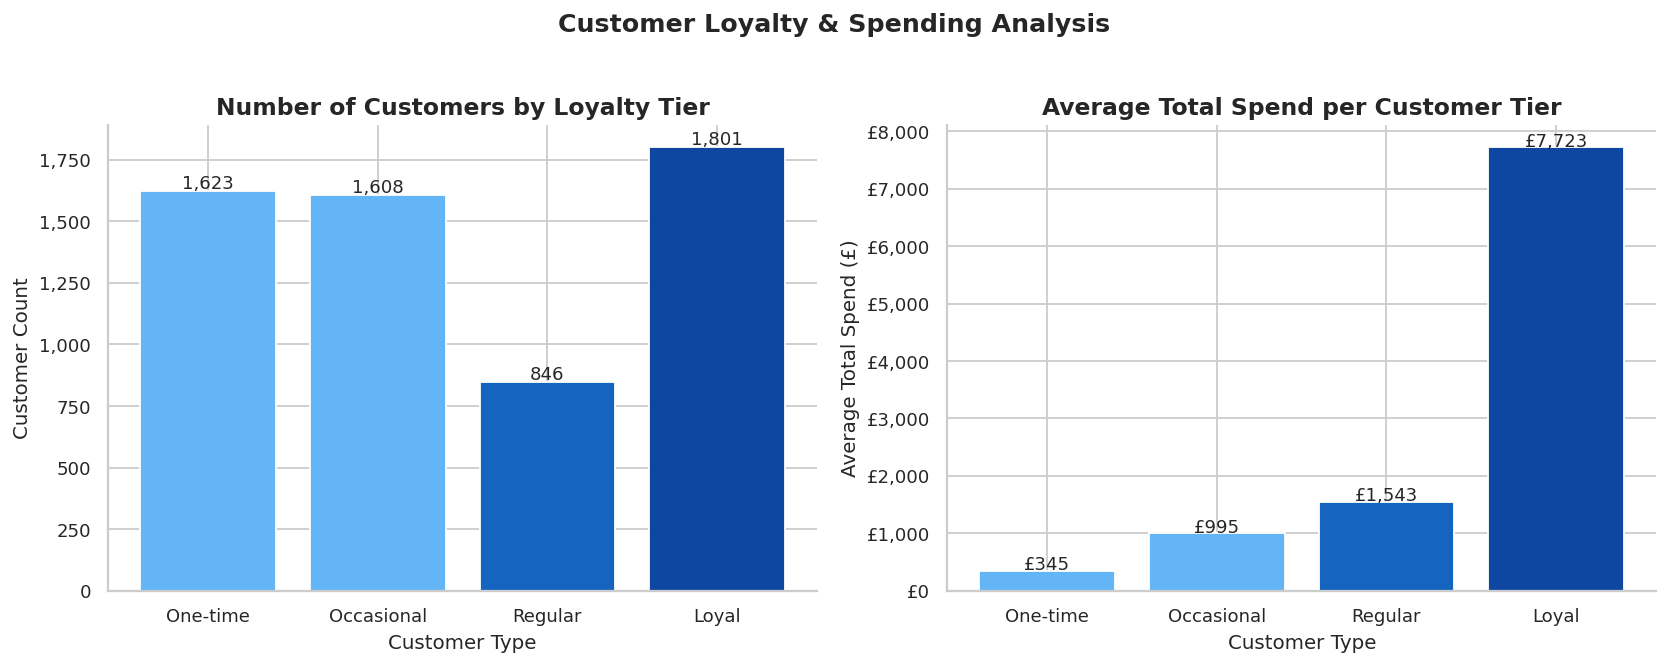

Retention chart saved.


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
short_labels = ["One-time", "Occasional", "Regular", "Loyal"]
bar_colors   = [BLUE_LIGHT, "#64B5F6", BLUE_MID, BLUE_DARK]

# ── Left: customer count per tier ────────────────────────────────────────────
bars1 = axes[0].bar(short_labels, type_summary["CustomerCount"],
                    color=bar_colors, edgecolor="white")
for bar in bars1:
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 10,
                 f"{int(bar.get_height()):,}", ha="center", fontsize=10)
axes[0].set_title("Number of Customers by Loyalty Tier", fontweight="bold")
axes[0].set_ylabel("Customer Count")
axes[0].set_xlabel("Customer Type")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

# ── Right: average spend per tier ─────────────────────────────────────────────
bars2 = axes[1].bar(short_labels, type_summary["AvgSpend"],
                    color=bar_colors, edgecolor="white")
for bar in bars2:
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 20,
                 f"£{bar.get_height():,.0f}", ha="center", fontsize=10)
axes[1].set_title("Average Total Spend per Customer Tier", fontweight="bold")
axes[1].set_ylabel("Average Total Spend (£)")
axes[1].set_xlabel("Customer Type")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"£{x:,.0f}"))

plt.suptitle("Customer Loyalty & Spending Analysis", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("output/trends/chart_customer_retention.png", bbox_inches="tight")
plt.show()
print("Retention chart saved.")

**Interpretation:** Loyal customers (6+ orders) have the highest average total spend per customer — often 5–10× more than one-time buyers. While one-time and occasional buyers are more numerous by count, loyal customers generate disproportionately high revenue per head. This confirms that customer retention strategies (loyalty programmes, personalised marketing, exclusive offers) would produce strong returns. Even converting 10% of occasional buyers to regular buyers could materially increase overall revenue.

## 13. Save All Results — HDFS & Local

In [16]:
# Save recommendations to HDFS
recs_spark = spark.createDataFrame(recommendations_df)
recs_spark.write.parquet(
    "hdfs://localhost:8020/retail/output/recommendations/",
    mode="overwrite"
)
print("Recommendations saved to HDFS.")

# Save monthly trends to HDFS
spark.createDataFrame(monthly).write.parquet(
    "hdfs://localhost:8020/retail/output/trends/monthly/",
    mode="overwrite"
)

# Save quarterly trends to HDFS
spark.createDataFrame(quarterly).write.parquet(
    "hdfs://localhost:8020/retail/output/trends/quarterly/",
    mode="overwrite"
)
print("Trends saved to HDFS.")

# Save locally as CSV
recommendations_df.to_csv(
    "output/recommendations/recommendations_top5_products.csv", index=False
)
print("CSV saved: output/recommendations/recommendations_top5_products.csv")
print("\nAll files saved. Notebook 04 complete.")

Recommendations saved to HDFS.
Trends saved to HDFS.
CSV saved: output/recommendations/recommendations_top5_products.csv

All files saved. Notebook 04 complete.


In [17]:
# List all saved output files
print("Output files:")
for root, dirs, files in os.walk("output"):
    for f in sorted(files):
        path = os.path.join(root, f)
        size = os.path.getsize(path)
        print(f"  {path:<62} ({size:,} bytes)")

Output files:
  output/visualisations/chart1_top10_countries.png               (47,502 bytes)
  output/visualisations/chart2_monthly_revenue.png               (87,664 bytes)
  output/visualisations/chart3_top10_products.png                (69,488 bytes)
  output/visualisations/chart4_orders_by_day.png                 (72,425 bytes)
  output/visualisations/chart5_order_distribution.png            (45,852 bytes)
  output/visualisations/chart6_top_customers.png                 (61,545 bytes)
  output/visualisations/chart7_heatmap.png                       (86,090 bytes)
  output/visualisations/dataset_summary.csv                      (135 bytes)
  output/visualisations/monthly_revenue.csv                      (601 bytes)
  output/visualisations/orders_by_day.csv                        (182 bytes)
  output/visualisations/top10_customers.csv                      (341 bytes)
  output/visualisations/top10_products.csv                       (759 bytes)
  output/cleaned_data/retail_cleaned_full

26/04/26 12:43:55 WARN HeartbeatReceiver: Removing executor driver with no recent heartbeats: 906035 ms exceeds timeout 120000 ms
26/04/26 12:43:55 WARN SparkContext: Killing executors is not supported by current scheduler.
26/04/26 12:48:33 ERROR Inbox: Ignoring error
org.apache.spark.SparkException: Exception thrown in awaitResult: 
	at org.apache.spark.util.SparkThreadUtils$.awaitResult(SparkThreadUtils.scala:53)
	at org.apache.spark.util.ThreadUtils$.awaitResult(ThreadUtils.scala:359)
	at org.apache.spark.rpc.RpcTimeout.awaitResult(RpcTimeout.scala:75)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRefByURI(RpcEnv.scala:102)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRef(RpcEnv.scala:110)
	at org.apache.spark.util.RpcUtils$.makeDriverRef(RpcUtils.scala:36)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.driverEndpoint$lzycompute(BlockManagerMasterEndpoint.scala:132)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.org$apache$spark$storage$BlockManagerMasterEndpoint$$

---
## Summary

### Part 1 — Recommendations
| Step | Action | Design Pattern |
|------|--------|----------------|
| 1 | Build customer-product matrix | Aggregation |
| 2 | Find customers who bought target product | Filtering |
| 3 | Find other products those customers bought | JOIN |
| 4 | Count shared customers per product pair | Aggregation |
| 5 | Rank by shared customer count | Sorting / Top-K |

### Part 2 — Trends
| Chart | What It Shows | Key Finding |
|-------|--------------|-------------|
| Monthly | Revenue + orders by month | Nov peak; strong YoY growth |
| Quarterly | Q1–Q4 per year | Q4 >> all others; 2011 highest |
| AOV | Average order value over time | Seasonal spikes pre-Christmas |
| Country products | Top 5 products per country | Different preferences by market |
| Retention | Loyalty tiers vs spend | Loyal = 5–10× higher avg spend |